# S05 · Your first five charts

Five seaborn functions cover most of the charts you will ever need at work. We draw all five, on real data, and see that they are the same call with a different name.


**New here? Read this once.**

- Never drawn a chart in code? You can still do this whole notebook. Press
  the play button on each cell, top to bottom, and read the plain-English
  note above it.
- Every seaborn chart is the *same* call: you hand it a table, say which
  column goes across, which goes up, and it draws. That is the whole trick.
- Already know matplotlib? Look for the cells marked **Stretch (optional)**.
- Stuck on a word? It is in `primers/glossary.md`.

## Setup
On **Google Colab**, run the next cell once. On your **own machine** you already installed everything with `uv`, so it does nothing there.

In [1]:
# seaborn ships with Colab, but we pin it up to date just in case.
import sys
if "google.colab" in sys.modules:
    !pip install -q "seaborn>=0.13"
else:
    print("Not on Colab - assuming seaborn is already installed.")

Not on Colab - assuming seaborn is already installed.


## The one line you always write first

Three imports and a theme. `pandas` holds the table, `seaborn` draws the chart, and `matplotlib` is the canvas seaborn draws on — you need it to add a title or to show the figure.

The `load` function below is a small convenience for this course. It reads the dataset from the `data/` folder when you have the course repo, and downloads it otherwise, so this notebook works even if the classroom wifi is down.

In [2]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def load(name):
    """Load a sample dataset: the copy in this repo first, else download it."""
    local = Path("../data") / f"{name}.csv"
    if local.exists():
        return pd.read_csv(local)
    return sns.load_dataset(name)


# One line, and every chart in this notebook comes out looking the same.
sns.set_theme(style="whitegrid")

print("Ready.")

Ready.


## Step 1 — meet the data

`tips` is a restaurant's record of 244 bills: what the meal cost, what was tipped, who paid, and when. It is small enough to read and rich enough to ask real questions of.

Always look at a table before you draw it. `head()` shows the first few rows and `shape` tells you (rows, columns).

In [3]:
tips = load("tips")

print("shape:", tips.shape)
print("columns:", list(tips.columns))

tips.head()

shape: (244, 7)
columns: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### The one signature

Before the charts, the idea that makes seaborn easy. Nearly every seaborn function takes the same arguments:

| Argument | What it does |
|---|---|
| `data` | the table to draw from |
| `x` | which column runs across the page |
| `y` | which column runs up the page |
| `hue` | which column decides the **colour** |
| `style` | which column decides the marker or dash pattern |
| `size` | which column decides how big the marker is |
| `palette` | which set of colours to use |

Learn those seven once and every chart below is the same sentence with a different verb. That is the whole session.

## Step 2 — `scatterplot`: is there a relationship?

A **scatter plot** puts one dot per row: across for one number, up for another. Use it when you want to know whether two numbers move together.

Here: do bigger bills get bigger tips?

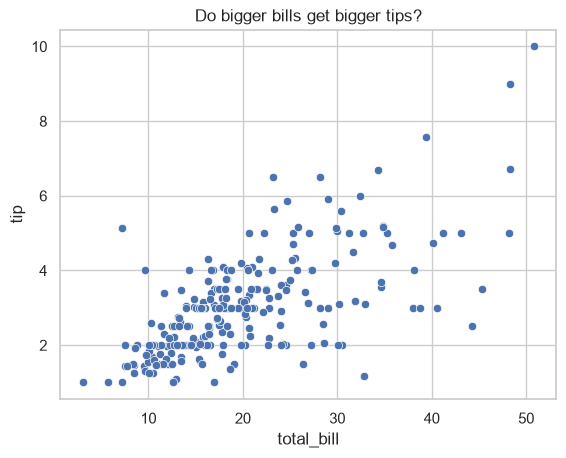

In [4]:
sns.scatterplot(data=tips, x="total_bill", y="tip")

plt.title("Do bigger bills get bigger tips?")
plt.show()

The cloud drifts up to the right, so yes — bigger bills do tend to bring bigger tips.

### Adding `hue` — a third column, for free

The chart above uses two columns. Add `hue` and you get a third, shown as colour, without changing anything else about the call.

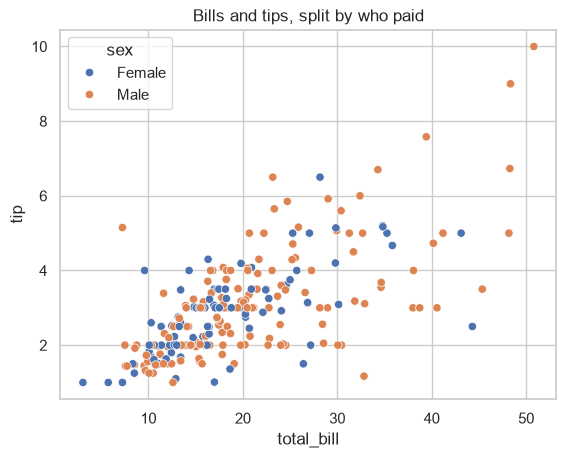

In [5]:
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="sex")

plt.title("Bills and tips, split by who paid")
plt.show()

### Your turn (2 min)

1. Change `hue="sex"` to `hue="smoker"`. Does the pattern differ?
2. Add `style="time"` as well. Lunch and dinner now get different marker shapes.
3. Ask yourself: at what point does the chart become too busy to read?

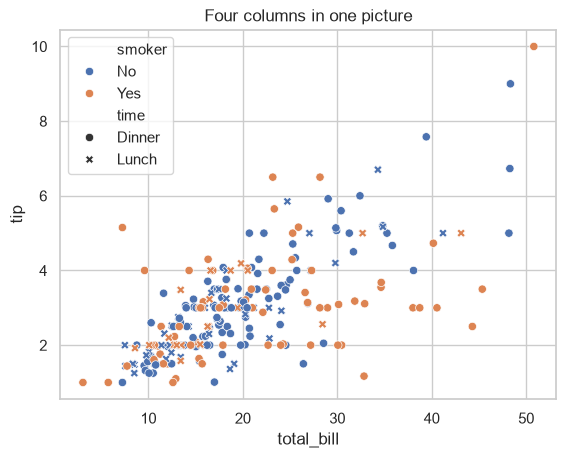

In [6]:
# Try it here.
sns.scatterplot(data=tips, x="total_bill", y="tip",
                hue="smoker", style="time")

plt.title("Four columns in one picture")
plt.show()

## Step 3 — `lineplot`: what happened over time?

A **line plot** joins points in order along the x-axis. The joining line says "these points follow one another", so use it when x is time and nothing else.

`flights` records monthly airline passengers from 1949 to 1960.

In [7]:
flights = load("flights")
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


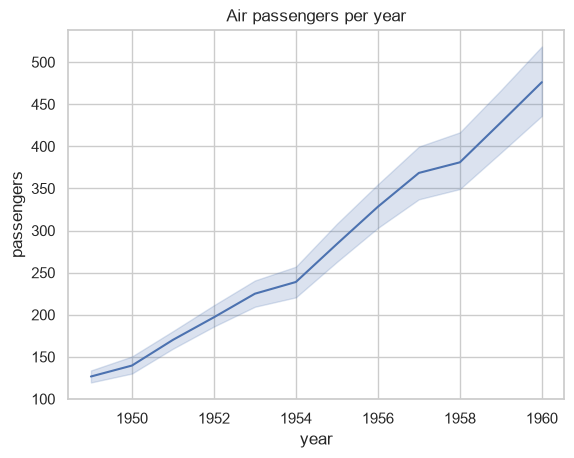

In [8]:
sns.lineplot(data=flights, x="year", y="passengers")

plt.title("Air passengers per year")
plt.show()

Two things worth noticing. The trend climbs steadily — air travel grew through the 1950s. And there is a pale band around the line: seaborn found twelve rows per year (one per month), so it drew the **average** and shaded how much the months varied. It summarised for you.

## Step 4 — `barplot`: compare categories

A **bar plot** compares one number across categories. Bars start at zero and the eye compares their lengths, which is why bars are the safest chart you can draw.

By default seaborn's bar height is the **mean** of `y` in each category, with a thin line showing the uncertainty.

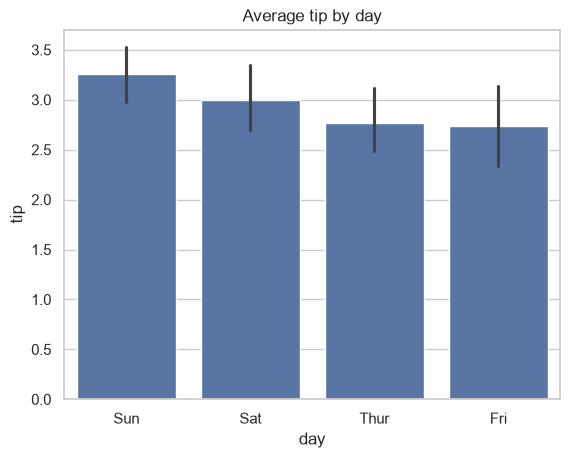

In [9]:
sns.barplot(data=tips, x="day", y="tip")

plt.title("Average tip by day")
plt.show()

And the same chart split by a second column, again with `hue`:

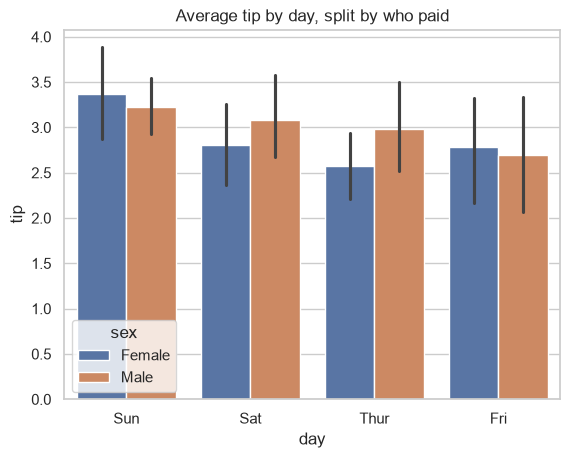

In [10]:
sns.barplot(data=tips, x="day", y="tip", hue="sex")

plt.title("Average tip by day, split by who paid")
plt.show()

## Step 5 — `histplot`: what shape is one column?

A **histogram** takes a single column of numbers, chops the range into bins, and counts how many rows land in each. It answers "where do the values cluster, and how spread out are they?"

Note there is no `y` here. You give it one column and it counts.

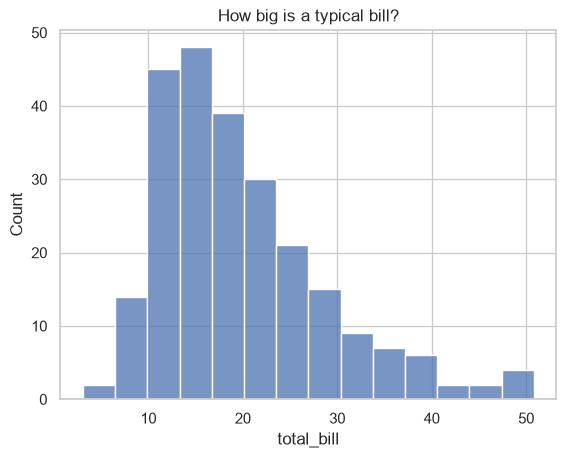

In [11]:
sns.histplot(data=tips, x="total_bill")

plt.title("How big is a typical bill?")
plt.show()

Most bills sit between 10 and 20, with a long thin tail to the right — a few large tables. That lopsided shape is called a **skew**, and you would never have seen it from an average alone.

`kde=True` lays a smooth curve over the bars for the same shape:

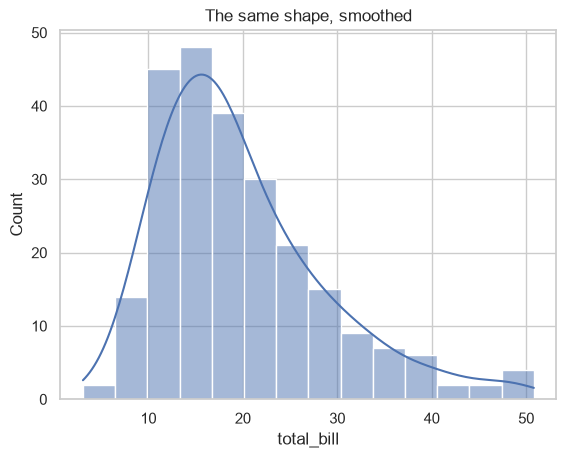

In [12]:
sns.histplot(data=tips, x="total_bill", kde=True)

plt.title("The same shape, smoothed")
plt.show()

## Step 6 — `boxplot`: compare shapes, and spot outliers

A **box plot** squeezes a whole distribution into one box so you can line several up side by side. The line inside the box is the **median**, the box holds the middle half of the data, the whiskers reach most of the rest, and the loose dots are **outliers** worth asking about.

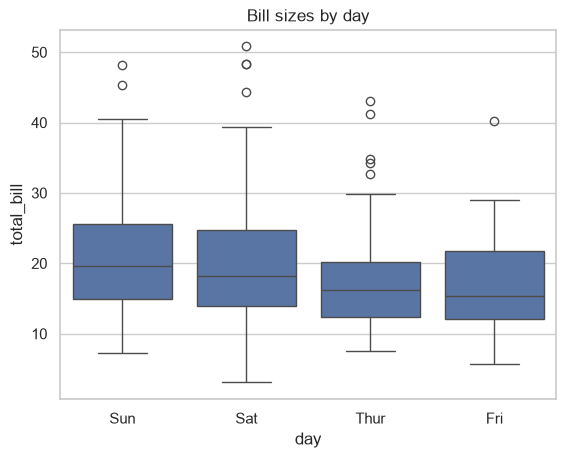

In [13]:
sns.boxplot(data=tips, x="day", y="total_bill")

plt.title("Bill sizes by day")
plt.show()

Saturday and Sunday sit higher, and each day has a few unusually large bills sticking out above the whisker. Those dots are the tables worth looking up in the records.

### Your turn (4 min)

You now have all five. Answer each question with **one** of them:

1. Does the size of the group (`size`) relate to the tip?
2. What is the shape of the `tip` column on its own?
3. Do lunch and dinner (`time`) have different bill sizes?

Write the chart for each in the cell below.

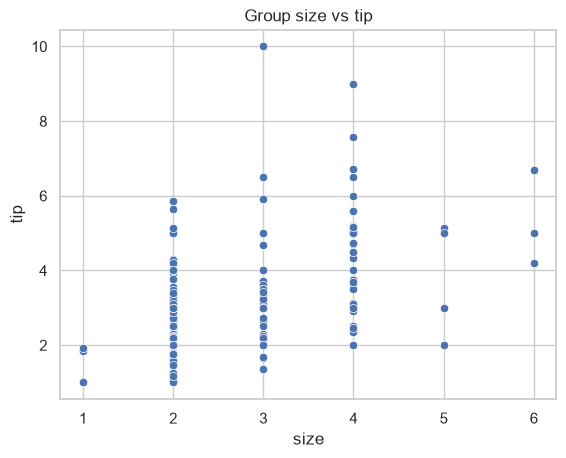

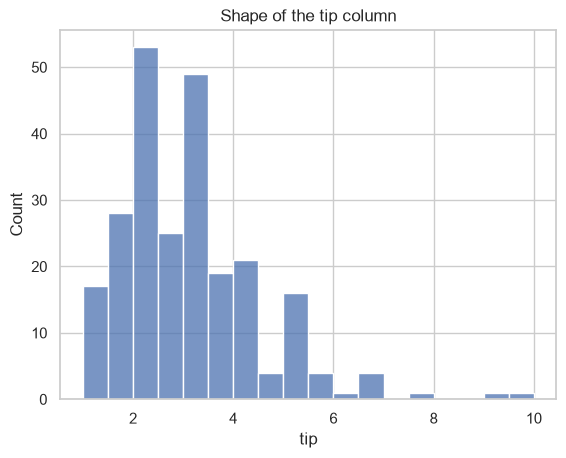

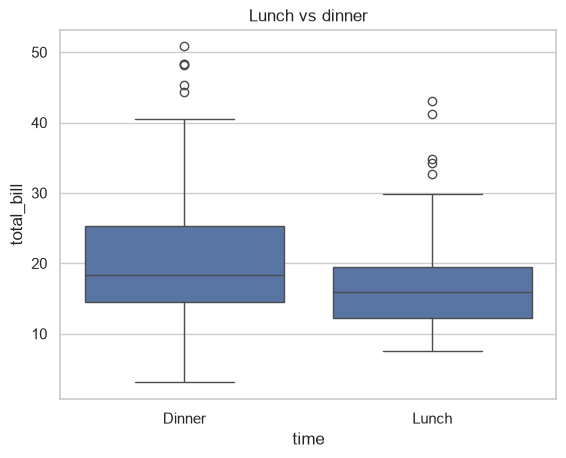

In [14]:
# 1. two numbers -> scatter
sns.scatterplot(data=tips, x="size", y="tip")
plt.title("Group size vs tip")
plt.show()

# 2. one number -> histogram
sns.histplot(data=tips, x="tip")
plt.title("Shape of the tip column")
plt.show()

# 3. a number across categories -> box
sns.boxplot(data=tips, x="time", y="total_bill")
plt.title("Lunch vs dinner")
plt.show()

### Stretch (optional)

Seaborn is built on matplotlib, and every seaborn call returns a matplotlib **axes** object. Catch it and you can adjust anything: axis labels, limits, tick rotation. This is how you go from a chart that works to a chart you would put in front of a client.

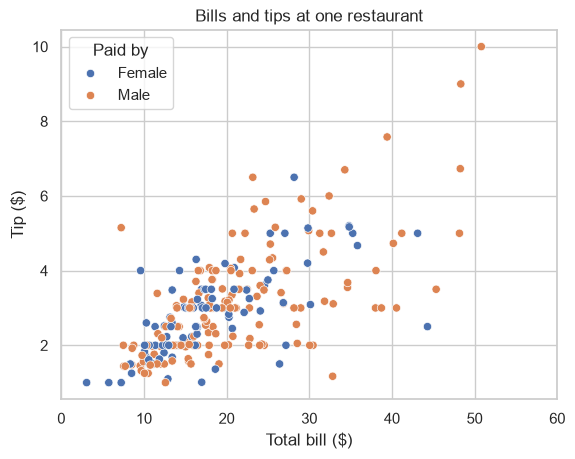

In [15]:
ax = sns.scatterplot(data=tips, x="total_bill", y="tip", hue="sex")

ax.set_xlabel("Total bill ($)")
ax.set_ylabel("Tip ($)")
ax.set_title("Bills and tips at one restaurant")
ax.set_xlim(0, 60)
ax.legend(title="Paid by")
plt.show()

## What you can do now

Five functions, one signature:

| Question | Function |
|---|---|
| Do two numbers move together? | `scatterplot` |
| What happened over time? | `lineplot` |
| How do categories compare? | `barplot` |
| What shape is one column? | `histplot` |
| How do shapes compare, and what is odd? | `boxplot` |

Next notebook: five more that handle counts, distributions and correlations.